In [17]:
# phase2_MMI_sweep.py
# MEEP 3D FDTD: sweep MMI length for 50/50 splitting at 1550 nm
# Reference geometry: [R6], waveguide from Phase 1

import meep as mp
import numpy as np
import scipy.io
import matplotlib.pyplot as plt

In [27]:

# ── Units: µm, c = 1 ───────────────────────────────────────────────────────
lam = 1.55
f0  = 1.0 / lam
df  = 0.15 / lam   # source bandwidth

# ── Materials ───────────────────────────────────────────────────────────────
LNO  = mp.Medium(epsilon_diag=mp.Vector3(2.138**2, 2.211**2, 2.211**2))
SiO2 = mp.Medium(index=1.444)


# ── Material indices at 1550 nm (Zelmon et al. 1997 [R5]) ──────────────────
n_e  = 2.138   # LNO extraordinary (TE mode, X-cut: c-axis along x)
n_o  = 2.211   # LNO ordinary
n_ox = 1.444   # SiO₂ BOX
n_air = 1.0

In [19]:

# ── Fixed geometry parameters ───────────────────────────────────────────────
h       = 0.30    # LNO core height
wg_w    = 0.90    # input/output waveguide width
W_MMI   = 5.5     # MMI body width (sweep W in a second pass if needed)
taper_L = 2.0     # linear taper length (wg_w → W_MMI at port)
port_off = W_MMI / 4  # = 1.375 µm — paired interference offset from center [R6]
pml_d   = 1.5     # PML thickness (µm)
wg_len  = 3.0     # input/output waveguide stub length beyond taper


In [20]:

def build_geometry(L_mmi, sx, sy, sz):
    """Build MEEP geometry list for 2×2 MMI with given body length."""
    x_mmi_c = 0.0    # MMI center at x = 0
    half_L  = L_mmi / 2

    geom = []

    # SiO₂ BOX (below LNO)
    geom.append(mp.Block(
        size=mp.Vector3(sx, sy, 2.0),
        center=mp.Vector3(0, 0, -(h/2 + 1.0)),
        material=SiO2
    ))

    # ── Input side (x < -half_L) ─────────────────────────────────────────
    # Upper input waveguide stub + taper
    x_in_wg_start = -(half_L + taper_L + wg_len)
    # Waveguide stub
    geom.append(mp.Block(
        size=mp.Vector3(wg_len, wg_w, h),
        center=mp.Vector3(x_in_wg_start + wg_len/2, +port_off, 0),
        material=LNO
    ))
    # Taper (approximated as block at full width — for accuracy use TrapezoidBlock
    # or break into small steps; sufficient for sweep at res=20)
    geom.append(mp.Block(
        size=mp.Vector3(taper_L, (wg_w + W_MMI/2)/2, h),
        center=mp.Vector3(-half_L - taper_L/2, +port_off/2, 0),
        material=LNO
    ))

    # Lower input waveguide (unused input port — terminated, or add second source)
    geom.append(mp.Block(
        size=mp.Vector3(wg_len, wg_w, h),
        center=mp.Vector3(x_in_wg_start + wg_len/2, -port_off, 0),
        material=LNO
    ))

    # ── MMI body ─────────────────────────────────────────────────────────
    geom.append(mp.Block(
        size=mp.Vector3(L_mmi, W_MMI, h),
        center=mp.Vector3(0, 0, 0),
        material=LNO
    ))

    # ── Output side (x > +half_L) ─────────────────────────────────────────
    for sign in [+1, -1]:
        # Taper
        geom.append(mp.Block(
            size=mp.Vector3(taper_L, (wg_w + W_MMI/2)/2, h),
            center=mp.Vector3(+half_L + taper_L/2, sign * port_off/2, 0),
            material=LNO
        ))
        # Output waveguide stub
        geom.append(mp.Block(
            size=mp.Vector3(wg_len, wg_w, h),
            center=mp.Vector3(+half_L + taper_L + wg_len/2, sign * port_off, 0),
            material=LNO
        ))

    return geom



In [21]:
###################### 3D #################################
# def run_mmi_sim(L_mmi, resolution=20):
#     """
#     Run MEEP 3D simulation of 2×2 MMI.
#     Returns (T_out_upper, T_out_lower) normalized by straight-wg reference.
#     """
#     total_x = pml_d + wg_len + taper_L + L_mmi + taper_L + wg_len + pml_d
#     sy_cell  = W_MMI + 4.0 + 2 * pml_d
#     sz_cell  = h + 4.5 + 2 * pml_d

#     cell = mp.Vector3(total_x, sy_cell, sz_cell)
#     half_tx = total_x / 2

#     geom = build_geometry(L_mmi, total_x, sy_cell, sz_cell)

#     # Source: TE eigenmode at upper input waveguide
#     x_src = -half_tx + pml_d + 0.5
#     src = [mp.EigenModeSource(
#         src=mp.GaussianSource(f0, fwidth=df),
#         center=mp.Vector3(x_src, +port_off, 0),
#         size=mp.Vector3(0, wg_w + 1.5, h + 1.5),
#         eig_band=1,
#         eig_parity=mp.ODD_Y + mp.EVEN_Z,  # TE-like
#         direction=mp.X,
#     )]

#     # Output flux monitors at both output ports
#     x_mon = +half_tx - pml_d - 0.5
#     L_half = L_mmi / 2
#     mon_upper = mp.FluxRegion(
#         center=mp.Vector3(x_mon, +port_off, 0),
#         size=mp.Vector3(0, wg_w + 1.0, h + 1.0)
#     )
#     mon_lower = mp.FluxRegion(
#         center=mp.Vector3(x_mon, -port_off, 0),
#         size=mp.Vector3(0, wg_w + 1.0, h + 1.0)
#     )

#     sim = mp.Simulation(
#         cell_size=cell,
#         boundary_layers=[mp.PML(pml_d)],
#         geometry=geom,
#         sources=src,
#         resolution=resolution,
#         default_material=mp.Medium(index=1.0),
#     )

#     flux_upper = sim.add_flux(f0, df, 100, mon_upper)
#     flux_lower = sim.add_flux(f0, df, 100, mon_lower)

#     sim.run(until_after_sources=mp.stop_when_fields_decayed(
#         50, mp.Ex,
#         mp.Vector3(x_mon, +port_off, 0),
#         1e-4
#     ))

#     T_upper = mp.get_fluxes(flux_upper)[0]
#     T_lower = mp.get_fluxes(flux_lower)[0]

#     sim.reset_meep()
#     return T_upper, T_lower



In [22]:
###################### 2D #################################
def run_mmi_sim(L_mmi, resolution=10):
    total_x = pml_d + wg_len + taper_L + L_mmi + taper_L + wg_len + pml_d
    sy_cell  = W_MMI + 4.0 + 2 * pml_d   # only x and y in 2D

    cell = mp.Vector3(total_x, sy_cell)   # no z component → 2D
    half_tx = total_x / 2

    geom = []
    # SiO2 BOX — in 2D just set background index; or use a block
    # LNO MMI body
    geom.append(mp.Block(
        size=mp.Vector3(L_mmi, W_MMI),
        center=mp.Vector3(0, 0),
        material=LNO,
    ))
    # input/output waveguide stubs
    for sign in [+1, -1]:
        geom.append(mp.Block(
            size=mp.Vector3(wg_len + taper_L, wg_w),
            center=mp.Vector3(-(half_tx - pml_d - (wg_len+taper_L)/2), sign*port_off),
            material=LNO,
        ))
        geom.append(mp.Block(
            size=mp.Vector3(wg_len + taper_L, wg_w),
            center=mp.Vector3(+(half_tx - pml_d - (wg_len+taper_L)/2), sign*port_off),
            material=LNO,
        ))

    x_src = -half_tx + pml_d + 0.5
    src = [mp.EigenModeSource(
        src=mp.GaussianSource(f0, fwidth=df),
        center=mp.Vector3(x_src, +port_off),
        size=mp.Vector3(0, wg_w + 1.5),
        eig_band=1,
        eig_parity=mp.ODD_Y,
        direction=mp.X,
    )]

    x_mon = +half_tx - pml_d - 0.5
    sim = mp.Simulation(
        cell_size=cell,
        dimensions=2,                        # ← 2D
        boundary_layers=[mp.PML(pml_d)],
        geometry=geom,
        sources=src,
        resolution=resolution,
        default_material=mp.Medium(index=n_ox),  # background = SiO2 (substrate)
    )

    flux_upper = sim.add_flux(f0, df, 100,
        mp.FluxRegion(center=mp.Vector3(x_mon, +port_off),
                      size=mp.Vector3(0, wg_w + 1.0)))
    flux_lower = sim.add_flux(f0, df, 100,
        mp.FluxRegion(center=mp.Vector3(x_mon, -port_off),
                      size=mp.Vector3(0, wg_w + 1.0)))

    sim.run(until_after_sources=mp.stop_when_fields_decayed(
        50, mp.Ez,                           # Ez in 2D TE
        mp.Vector3(x_mon, +port_off), 1e-4))

    T_upper = mp.get_fluxes(flux_upper)[0]
    T_lower = mp.get_fluxes(flux_lower)[0]
    sim.reset_meep()
    return T_upper, T_lower

In [23]:
# # ── Reference simulation (straight waveguide, for normalization) ──────────
# ###################### 3D #################################

# def run_reference(resolution=20):
#     """Straight waveguide — measures input power P_ref."""
#     ref_len = 20.0   # arbitrary straight length
#     total_x = pml_d + wg_len + ref_len + wg_len + pml_d
#     sy_c = wg_w + 3.0 + 2 * pml_d
#     sz_c = h + 4.0 + 2 * pml_d
#     cell = mp.Vector3(total_x, sy_c, sz_c)
#     half_tx = total_x / 2
#     x_src = -half_tx + pml_d + 0.5
#     x_mon = +half_tx - pml_d - 0.5

#     geom = [
#         mp.Block(mp.Vector3(total_x, sy_c, 2.0),
#                  center=mp.Vector3(0, 0, -(h/2 + 1.0)), material=SiO2),
#         mp.Block(mp.Vector3(total_x, wg_w, h),
#                  center=mp.Vector3(0, 0, 0), material=LNO),
#     ]
#     src = [mp.EigenModeSource(
#         mp.GaussianSource(f0, fwidth=df),
#         center=mp.Vector3(x_src, 0, 0),
#         size=mp.Vector3(0, wg_w + 1.5, h + 1.5),
#         eig_band=1, eig_parity=mp.ODD_Y + mp.EVEN_Z, direction=mp.X,
#     )]
#     sim = mp.Simulation(
#         cell_size=cell, boundary_layers=[mp.PML(pml_d)],
#         geometry=geom, sources=src, resolution=resolution,
#         default_material=mp.Medium(index=1.0),
#     )
#     flux = sim.add_flux(f0, df, 100,
#                         mp.FluxRegion(center=mp.Vector3(x_mon, 0, 0),
#                                       size=mp.Vector3(0, wg_w + 1.0, h + 1.0)))
#     sim.run(until_after_sources=mp.stop_when_fields_decayed(
#         50, mp.Ex, mp.Vector3(x_mon, 0, 0), 1e-4))
#     P_ref = mp.get_fluxes(flux)[0]
#     sim.reset_meep()
#     return P_ref



In [24]:
# ── Reference simulation (straight waveguide, for normalization) ──────────
###################### 2D #################################
def run_reference(resolution=10):
    """Straight waveguide in 2D — measures input power P_ref."""
    ref_len = 20.0
    total_x = pml_d + wg_len + ref_len + wg_len + pml_d
    sy_c = wg_w + 3.0 + 2 * pml_d

    cell = mp.Vector3(total_x, sy_c)   # 2D — no z
    half_tx = total_x / 2
    x_src = -half_tx + pml_d + 0.5
    x_mon = +half_tx - pml_d - 0.5

    geom = [
        mp.Block(
            size=mp.Vector3(total_x, wg_w),
            center=mp.Vector3(0, 0),
            material=LNO
        ),
    ]

    src = [mp.EigenModeSource(
        mp.GaussianSource(f0, fwidth=df),
        center=mp.Vector3(x_src, 0),
        size=mp.Vector3(0, wg_w + 1.5),
        eig_band=1,
        eig_parity=mp.ODD_Y,
        direction=mp.X,
    )]

    sim = mp.Simulation(
        cell_size=cell,
        dimensions=2,                        # 2D
        boundary_layers=[mp.PML(pml_d)],
        geometry=geom,
        sources=src,
        resolution=resolution,
        default_material=mp.Medium(index=n_ox),   # background = SiO2
    )

    flux = sim.add_flux(f0, df, 100,
        mp.FluxRegion(
            center=mp.Vector3(x_mon, 0),
            size=mp.Vector3(0, wg_w + 1.0)
        ))

    sim.run(until_after_sources=mp.stop_when_fields_decayed(
        50, mp.Ez,                           # Ez in 2D TE
        mp.Vector3(x_mon, 0),
        1e-4
    ))

    P_ref = mp.get_fluxes(flux)[0]
    sim.reset_meep()
    return P_ref

In [28]:

# ── Main sweep ─────────────────────────────────────────────────────────────
print("Running reference simulation...")
P_ref = run_reference(resolution=20)
print(f"P_ref = {P_ref:.6f}")

L_sweep = np.arange(10, 56, 2)   # coarse: 10 to 54 µm in 2 µm steps
T_upper_list, T_lower_list = [], []

print(f"\n{'L (µm)':>8}  {'T_upper':>9}  {'T_lower':>9}  {'T_total':>9}  {'ratio':>7}")
for L in L_sweep:
    tu, tl = run_mmi_sim(L, resolution=20)
    tu_norm = tu / P_ref
    tl_norm = tl / P_ref
    tt = tu_norm + tl_norm
    ratio = tu_norm / tt if tt > 0 else 0
    T_upper_list.append(tu_norm)
    T_lower_list.append(tl_norm)
    print(f"{L:>8.0f}  {tu_norm:>9.4f}  {tl_norm:>9.4f}  {tt:>9.4f}  {ratio:>7.3f}")

T_upper = np.array(T_upper_list)
T_lower = np.array(T_lower_list)
T_total = T_upper + T_lower
imbalance = np.abs(T_upper - T_lower)

# Candidate points: high total T and low imbalance
valid = T_total > 0.80 * np.max(T_total)
if valid.any():
    best_idx = np.argmin(imbalance[valid])
    best_L = L_sweep[valid][best_idx]
    print(f"\nCoarse optimum: L ≈ {best_L} µm")
    print(f"At best_L: T_upper={T_upper[valid][best_idx]:.4f}, "
          f"T_lower={T_lower[valid][best_idx]:.4f}")
else:
    print("No optimum found in sweep range — extend range!")
    best_L = None


Running reference simulation...
-----------
Initializing structure...
time for choose_chunkdivision = 0.000256269 s
Working in 2D dimensions.
Computational cell is 29 x 6.9 x 0 with resolution 20
     block, center = (0,0,0)
          size (29,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
time for set_epsilon = 0.111615 s
-----------
MPB solved for frequency_1(1.41022,0,0) = 0.676616 after 16 iters
MPB solved for frequency_1(1.33778,0,0) = 0.645199 after 7 iters
MPB solved for frequency_1(1.33769,0,0) = 0.645161 after 3 iters
MPB solved for frequency_1(1.33769,0,0) = 0.645161 after 1 iters
field decay(t = 50.025000000000006): 1.014018322540601e-58 / 1.014018322540601e-58 = 1.0
field decay(t = 100.05000000000001): 4.491974694886881e-48 / 4.491974694886881e-48 = 1.0
on time step 5261 (time=131.525), 0.00076032 s/step
field decay(t = 150.07500000000002): 1.4195217061210088e-46 / 1.4195217061210088e-46 = 1.0
field

MPB solved for frequency_1(1.41022,0,0) = 0.67629 after 15 iters
MPB solved for frequency_1(1.33858,0,0) = 0.645198 after 7 iters
MPB solved for frequency_1(1.33849,0,0) = 0.645161 after 3 iters
MPB solved for frequency_1(1.33849,0,0) = 0.645161 after 1 iters
field decay(t = 50.025000000000006): 1.8195386282408563e-24 / 1.8195386282408563e-24 = 1.0
field decay(t = 100.05000000000001): 2.304649377955606e-16 / 2.304649377955606e-16 = 1.0
on time step 4800 (time=120), 0.000833364 s/step
field decay(t = 150.07500000000002): 1.9715284198522787e-16 / 2.304649377955606e-16 = 0.8554569899917573
field decay(t = 200.10000000000002): 7.430487909238782e-19 / 2.304649377955606e-16 = 0.0032241294403880963
on time step 9735 (time=243.375), 0.000810639 s/step
field decay(t = 250.125): 2.2078622533462756e-19 / 2.304649377955606e-16 = 0.0009580035360106761
field decay(t = 300.15000000000003): 6.135649234757262e-21 / 2.304649377955606e-16 = 2.6622918407658328e-05
run 0 finished at t = 300.15000000000003 

MPB solved for frequency_1(1.41022,0,0) = 0.67629 after 15 iters
MPB solved for frequency_1(1.33858,0,0) = 0.645198 after 7 iters
MPB solved for frequency_1(1.33849,0,0) = 0.645161 after 3 iters
MPB solved for frequency_1(1.33849,0,0) = 0.645161 after 1 iters
field decay(t = 50.025000000000006): 4.456650063179443e-26 / 4.456650063179443e-26 = 1.0
field decay(t = 100.05000000000001): 1.3755074470057793e-16 / 1.3755074470057793e-16 = 1.0
on time step 4552 (time=113.8), 0.00087878 s/step
field decay(t = 150.07500000000002): 1.3578874826952823e-16 / 1.3755074470057793e-16 = 0.9871902079855311
field decay(t = 200.10000000000002): 7.958094626387038e-19 / 1.3755074470057793e-16 = 0.005785570004517468
on time step 9112 (time=227.8), 0.000877331 s/step
field decay(t = 250.125): 1.8123133030344309e-19 / 1.3755074470057793e-16 = 0.0013175597900102218
field decay(t = 300.15000000000003): 2.181523429010033e-21 / 1.3755074470057793e-16 = 1.5859771851899447e-05
run 0 finished at t = 300.1500000000000

MPB solved for frequency_1(1.41022,0,0) = 0.67629 after 15 iters
MPB solved for frequency_1(1.33858,0,0) = 0.645198 after 7 iters
MPB solved for frequency_1(1.33849,0,0) = 0.645161 after 3 iters
MPB solved for frequency_1(1.33849,0,0) = 0.645161 after 1 iters
field decay(t = 50.025000000000006): 8.070611296950315e-28 / 8.070611296950315e-28 = 1.0
field decay(t = 100.05000000000001): 2.13319250382335e-16 / 2.13319250382335e-16 = 1.0
on time step 4188 (time=104.7), 0.000955202 s/step
field decay(t = 150.07500000000002): 3.2159661440760703e-16 / 3.2159661440760703e-16 = 1.0
field decay(t = 200.10000000000002): 1.8473776775890534e-19 / 3.2159661440760703e-16 = 0.0005744394047779365
on time step 8470 (time=211.75), 0.00093424 s/step
field decay(t = 250.125): 8.736603953948186e-19 / 3.2159661440760703e-16 = 0.00271663430600516
field decay(t = 300.15000000000003): 5.3055336343312055e-21 / 3.2159661440760703e-16 = 1.6497479751471254e-05
run 0 finished at t = 300.15000000000003 (12006 timesteps

MPB solved for frequency_1(1.41022,0,0) = 0.67629 after 15 iters
MPB solved for frequency_1(1.33858,0,0) = 0.645198 after 7 iters
MPB solved for frequency_1(1.33849,0,0) = 0.645161 after 3 iters
MPB solved for frequency_1(1.33849,0,0) = 0.645161 after 1 iters
field decay(t = 50.025000000000006): 5.24045915367842e-29 / 5.24045915367842e-29 = 1.0
on time step 3956 (time=98.9), 0.0010112 s/step
field decay(t = 100.05000000000001): 4.1278746684732204e-17 / 4.1278746684732204e-17 = 1.0
field decay(t = 150.07500000000002): 1.217082076564285e-16 / 1.217082076564285e-16 = 1.0
field decay(t = 200.10000000000002): 4.001826577006708e-19 / 1.217082076564285e-16 = 0.0032880498809936556
on time step 8053 (time=201.325), 0.00097639 s/step
field decay(t = 250.125): 1.1186255121843151e-18 / 1.217082076564285e-16 = 0.009191044168049011
field decay(t = 300.15000000000003): 8.078047620437664e-20 / 1.217082076564285e-16 = 0.0006637225028603887
on time step 12173 (time=304.325), 0.00097108 s/step
field deca

...

MPB solved for frequency_1(1.41022,0,0) = 0.67629 after 15 iters
MPB solved for frequency_1(1.33858,0,0) = 0.645198 after 7 iters
MPB solved for frequency_1(1.33849,0,0) = 0.645161 after 3 iters
MPB solved for frequency_1(1.33849,0,0) = 0.645161 after 1 iters
on time step 1822 (time=45.55), 0.00219627 s/step
on time step 3697 (time=92.425), 0.00213343 s/step
field decay(t = 100.05000000000001): 3.3410222037809167e-28 / 3.3410222037809167e-28 = 1.0
on time step 5580 (time=139.5), 0.00212499 s/step
field decay(t = 150.07500000000002): 2.125340196407589e-21 / 2.125340196407589e-21 = 1.0
on time step 7468 (time=186.7), 0.00211926 s/step
field decay(t = 200.10000000000002): 5.5454576818066363e-17 / 5.5454576818066363e-17 = 1.0
on time step 9372 (time=234.3), 0.002101 s/step
field decay(t = 250.125): 8.030239974244122e-18 / 5.5454576818066363e-17 = 0.14480752419389084
on time step 11267 (time=281.675), 0.00211117 s/step
field decay(t = 300.15000000000003): 1.9689110826650781e-22 / 5.54545768

MPB solved for frequency_1(1.41022,0,0) = 0.67629 after 15 iters
MPB solved for frequency_1(1.33858,0,0) = 0.645198 after 7 iters
MPB solved for frequency_1(1.33849,0,0) = 0.645161 after 3 iters
MPB solved for frequency_1(1.33849,0,0) = 0.645161 after 1 iters
on time step 1746 (time=43.65), 0.00229171 s/step
on time step 3566 (time=89.15), 0.00219791 s/step
field decay(t = 100.05000000000001): 3.265154380861993e-29 / 3.265154380861993e-29 = 1.0
on time step 5337 (time=133.425), 0.00225947 s/step
field decay(t = 150.07500000000002): 3.261915296151172e-22 / 3.261915296151172e-22 = 1.0
on time step 7105 (time=177.625), 0.00226339 s/step
field decay(t = 200.10000000000002): 9.031296724457588e-17 / 9.031296724457588e-17 = 1.0
on time step 8909 (time=222.725), 0.00221846 s/step
field decay(t = 250.125): 2.4052604962581517e-17 / 9.031296724457588e-17 = 0.2663250438604773
on time step 10679 (time=266.975), 0.00226062 s/step
field decay(t = 300.15000000000003): 6.899826066768916e-22 / 9.0312967

MPB solved for frequency_1(1.41022,0,0) = 0.67629 after 15 iters
MPB solved for frequency_1(1.33858,0,0) = 0.645198 after 7 iters
MPB solved for frequency_1(1.33849,0,0) = 0.645161 after 3 iters
MPB solved for frequency_1(1.33849,0,0) = 0.645161 after 1 iters
on time step 1662 (time=41.55), 0.00240696 s/step
on time step 3345 (time=83.625), 0.00237779 s/step
field decay(t = 100.05000000000001): 3.367047094375534e-30 / 3.367047094375534e-30 = 1.0
on time step 5053 (time=126.325), 0.00234316 s/step
field decay(t = 150.07500000000002): 1.732917651220088e-22 / 1.732917651220088e-22 = 1.0
on time step 6745 (time=168.625), 0.00236464 s/step
field decay(t = 200.10000000000002): 1.6681825123261953e-16 / 1.6681825123261953e-16 = 1.0
on time step 8453 (time=211.325), 0.00234302 s/step
field decay(t = 250.125): 1.2098744216157824e-16 / 1.6681825123261953e-16 = 0.7252650190707696
on time step 10158 (time=253.95), 0.0023465 s/step
on time step 11929 (time=298.225), 0.00226036 s/step
field decay(t =

MPB solved for frequency_1(1.41022,0,0) = 0.67629 after 15 iters
MPB solved for frequency_1(1.33858,0,0) = 0.645198 after 7 iters
MPB solved for frequency_1(1.33849,0,0) = 0.645161 after 3 iters
MPB solved for frequency_1(1.33849,0,0) = 0.645161 after 1 iters
on time step 1646 (time=41.15), 0.00243017 s/step
on time step 3292 (time=82.3), 0.00243141 s/step
field decay(t = 100.05000000000001): 3.5627799031706516e-31 / 3.5627799031706516e-31 = 1.0
on time step 4957 (time=123.925), 0.00240242 s/step
field decay(t = 150.07500000000002): 1.005078846416318e-22 / 1.005078846416318e-22 = 1.0
on time step 6592 (time=164.8), 0.00244656 s/step
field decay(t = 200.10000000000002): 1.6985904700378646e-16 / 1.6985904700378646e-16 = 1.0
on time step 8269 (time=206.725), 0.00238573 s/step
on time step 9948 (time=248.7), 0.00238272 s/step
field decay(t = 250.125): 1.6457209420431932e-16 / 1.6985904700378646e-16 = 0.9688744703757269
on time step 11617 (time=290.425), 0.00239773 s/step
field decay(t = 30

MPB solved for frequency_1(1.41022,0,0) = 0.67629 after 15 iters
MPB solved for frequency_1(1.33858,0,0) = 0.645198 after 7 iters
MPB solved for frequency_1(1.33849,0,0) = 0.645161 after 3 iters
MPB solved for frequency_1(1.33849,0,0) = 0.645161 after 1 iters
on time step 1579 (time=39.475), 0.00253342 s/step
on time step 3195 (time=79.875), 0.00247623 s/step
field decay(t = 100.05000000000001): 1.8982277642723853e-32 / 1.8982277642723853e-32 = 1.0
on time step 4834 (time=120.85), 0.0024412 s/step
field decay(t = 150.07500000000002): 7.3696884621791e-23 / 7.3696884621791e-23 = 1.0
on time step 6436 (time=160.9), 0.00249831 s/step
field decay(t = 200.10000000000002): 7.224819757427964e-17 / 7.224819757427964e-17 = 1.0
on time step 8065 (time=201.625), 0.00245565 s/step
on time step 9684 (time=242.1), 0.00247068 s/step
field decay(t = 250.125): 6.431599134702676e-17 / 7.224819757427964e-17 = 0.890208939550393
on time step 11248 (time=281.2), 0.00255801 s/step
field decay(t = 300.15000000

In [29]:
# ── Fine sweep around best_L ────────────────────────────────────────────────
if best_L is not None:
    L_fine = np.linspace(best_L - 3, best_L + 3, 13)
    Tu_fine, Tl_fine = [], []
    for L in L_fine:
        tu, tl = run_mmi_sim(L, resolution=35)  # higher res for accuracy
        Tu_fine.append(tu / P_ref)
        Tl_fine.append(tl / P_ref)
    Tu_fine = np.array(Tu_fine)
    Tl_fine = np.array(Tl_fine)
    best_fine_idx = np.argmin(np.abs(Tu_fine - Tl_fine))
    L_opt = L_fine[best_fine_idx]
    IL_dB = -10 * np.log10(Tu_fine[best_fine_idx] + Tl_fine[best_fine_idx])
    split_pct = 100 * Tu_fine[best_fine_idx] / (Tu_fine[best_fine_idx] + Tl_fine[best_fine_idx])
    print(f"\nFine optimum: L_opt = {L_opt:.2f} µm")
    print(f"Split ratio: {split_pct:.1f}% / {100-split_pct:.1f}%")
    print(f"Insertion loss: {IL_dB:.2f} dB")
else:
    L_opt = None


-----------
Initializing structure...
time for choose_chunkdivision = 0.000857671 s
Working in 2D dimensions.
Computational cell is 64 x 12.5143 x 0 with resolution 35
     block, center = (0,0,0)
          size (51,5.5,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (-28,1.375,0)
          size (5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (28,1.375,0)
          size (5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (-28,-1.375,0)
          size (5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (28,-1.375,0)
          size (5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant ep

MPB solved for frequency_1(1.41022,0,0) = 0.67634 after 18 iters
MPB solved for frequency_1(1.33843,0,0) = 0.645199 after 6 iters
MPB solved for frequency_1(1.33834,0,0) = 0.645161 after 5 iters
MPB solved for frequency_1(1.33834,0,0) = 0.645161 after 1 iters
on time step 484 (time=6.91429), 0.00827329 s/step
on time step 1004 (time=14.3429), 0.0076968 s/step
on time step 1510 (time=21.5714), 0.00790782 s/step
on time step 2004 (time=28.6286), 0.00810574 s/step
on time step 2503 (time=35.7571), 0.00802657 s/step
on time step 3004 (time=42.9143), 0.00798766 s/step
on time step 3509 (time=50.1286), 0.00792576 s/step
on time step 4022 (time=57.4571), 0.00779769 s/step
on time step 4518 (time=64.5429), 0.00807283 s/step
on time step 5031 (time=71.8714), 0.00781188 s/step
on time step 5543 (time=79.1857), 0.00782472 s/step
on time step 6055 (time=86.5), 0.0078192 s/step
on time step 6574 (time=93.9143), 0.00771682 s/step
field decay(t = 100.02857142857142): 4.69335645308832e-28 / 4.69335645

field decay(t = 300.07142857142856): 1.3633775004676323e-19 / 5.418001480281617e-14 = 2.5163845108376873e-06
run 0 finished at t = 300.07142857142856 (21005 timesteps)
-----------
Initializing structure...
time for choose_chunkdivision = 0.000762855 s
Working in 2D dimensions.
Computational cell is 64.5143 x 12.5143 x 0 with resolution 35
     block, center = (0,0,0)
          size (51.5,5.5,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (-28.25,1.375,0)
          size (5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (28.25,1.375,0)
          size (5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (-28.25,-1.375,0)
          size (5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric con

MPB solved for frequency_1(1.41022,0,0) = 0.67634 after 18 iters
MPB solved for frequency_1(1.33843,0,0) = 0.645199 after 6 iters
MPB solved for frequency_1(1.33834,0,0) = 0.645161 after 5 iters
MPB solved for frequency_1(1.33834,0,0) = 0.645161 after 1 iters
on time step 496 (time=7.08571), 0.00808102 s/step
on time step 1024 (time=14.6286), 0.00758069 s/step
on time step 1545 (time=22.0714), 0.00768427 s/step
on time step 2059 (time=29.4143), 0.00778597 s/step
on time step 2581 (time=36.8714), 0.00767276 s/step
on time step 3100 (time=44.2857), 0.00771657 s/step
on time step 3611 (time=51.5857), 0.00783507 s/step
on time step 4138 (time=59.1143), 0.00759199 s/step
on time step 4662 (time=66.6), 0.007635 s/step
on time step 5180 (time=74), 0.00773054 s/step
on time step 5707 (time=81.5286), 0.00759884 s/step
on time step 6218 (time=88.8286), 0.00784192 s/step
on time step 6729 (time=96.1286), 0.00783973 s/step
field decay(t = 100.02857142857142): 2.395557161201579e-28 / 2.395557161201

field decay(t = 300.07142857142856): 3.571215550182747e-19 / 5.854779063615428e-14 = 6.099658947638341e-06
run 0 finished at t = 300.07142857142856 (21005 timesteps)
-----------
Initializing structure...
time for choose_chunkdivision = 0.000782121 s
Working in 2D dimensions.
Computational cell is 65 x 12.5143 x 0 with resolution 35
     block, center = (0,0,0)
          size (52,5.5,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (-28.5,1.375,0)
          size (5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (28.5,1.375,0)
          size (5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (-28.5,-1.375,0)
          size (5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilo

...

MPB solved for frequency_1(1.41022,0,0) = 0.67634 after 18 iters
MPB solved for frequency_1(1.33843,0,0) = 0.645199 after 6 iters
MPB solved for frequency_1(1.33834,0,0) = 0.645161 after 5 iters
MPB solved for frequency_1(1.33834,0,0) = 0.645161 after 1 iters
on time step 472 (time=6.74286), 0.00848109 s/step
on time step 958 (time=13.6857), 0.00823199 s/step
on time step 1443 (time=20.6143), 0.0082634 s/step
on time step 1933 (time=27.6143), 0.00816974 s/step
on time step 2421 (time=34.5857), 0.00820343 s/step
on time step 2912 (time=41.6), 0.00815518 s/step
on time step 3400 (time=48.5714), 0.00820392 s/step
on time step 3894 (time=55.6286), 0.00811145 s/step
on time step 4377 (time=62.5286), 0.00829157 s/step
on time step 4865 (time=69.5), 0.00820461 s/step
on time step 5357 (time=76.5286), 0.00814351 s/step
on time step 5847 (time=83.5286), 0.00816974 s/step
on time step 6337 (time=90.5286), 0.00816527 s/step
on time step 6825 (time=97.5), 0.00819939 s/step
field decay(t = 100.0285

field decay(t = 350.0857142857143): 4.697646161692048e-24 / 1.3115708186896971e-14 = 3.5816946326887275e-10
run 0 finished at t = 350.0857142857143 (24506 timesteps)
-----------
Initializing structure...
time for choose_chunkdivision = 0.000779245 s
Working in 2D dimensions.
Computational cell is 69.5143 x 12.5143 x 0 with resolution 35
     block, center = (0,0,0)
          size (56.5,5.5,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (-30.75,1.375,0)
          size (5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (30.75,1.375,0)
          size (5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (-30.75,-1.375,0)
          size (5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric const

MPB solved for frequency_1(1.41022,0,0) = 0.67634 after 18 iters
MPB solved for frequency_1(1.33843,0,0) = 0.645199 after 6 iters
MPB solved for frequency_1(1.33834,0,0) = 0.645161 after 5 iters
MPB solved for frequency_1(1.33834,0,0) = 0.645161 after 1 iters
on time step 470 (time=6.71429), 0.00852476 s/step
on time step 955 (time=13.6429), 0.00826061 s/step
on time step 1437 (time=20.5286), 0.00831263 s/step
on time step 1910 (time=27.2857), 0.00846333 s/step
on time step 2391 (time=34.1571), 0.00833114 s/step
on time step 2863 (time=40.9), 0.00847463 s/step
on time step 3327 (time=47.5286), 0.0086354 s/step
on time step 3793 (time=54.1857), 0.00859487 s/step
on time step 4274 (time=61.0571), 0.00831943 s/step
on time step 4763 (time=68.0429), 0.00818373 s/step
on time step 5246 (time=74.9429), 0.00828519 s/step
on time step 5727 (time=81.8143), 0.00832446 s/step
on time step 6221 (time=88.8714), 0.00810587 s/step
on time step 6708 (time=95.8286), 0.00821952 s/step
field decay(t = 10

field decay(t = 350.0857142857143): 1.4607422470337446e-23 / 1.1224819899050475e-14 = 1.3013502757022506e-09
run 0 finished at t = 350.0857142857143 (24506 timesteps)
-----------
Initializing structure...
time for choose_chunkdivision = 0.000781149 s
Working in 2D dimensions.
Computational cell is 70 x 12.5143 x 0 with resolution 35
     block, center = (0,0,0)
          size (57,5.5,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (-31,1.375,0)
          size (5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (31,1.375,0)
          size (5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (-31,-1.375,0)
          size (5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon dia

MPB solved for frequency_1(1.41022,0,0) = 0.67634 after 18 iters
MPB solved for frequency_1(1.33843,0,0) = 0.645199 after 6 iters
MPB solved for frequency_1(1.33834,0,0) = 0.645161 after 5 iters
MPB solved for frequency_1(1.33834,0,0) = 0.645161 after 1 iters
on time step 468 (time=6.68571), 0.0085509 s/step
on time step 962 (time=13.7429), 0.00810203 s/step
on time step 1461 (time=20.8714), 0.00802773 s/step
on time step 1954 (time=27.9143), 0.00812527 s/step
on time step 2445 (time=34.9286), 0.00816087 s/step
on time step 2938 (time=41.9714), 0.00811852 s/step
on time step 3431 (time=49.0143), 0.00812523 s/step
on time step 3926 (time=56.0857), 0.00808781 s/step
on time step 4405 (time=62.9286), 0.00836454 s/step
on time step 4886 (time=69.8), 0.00832909 s/step
on time step 5372 (time=76.7429), 0.00823748 s/step
on time step 5845 (time=83.5), 0.00846305 s/step
on time step 6332 (time=90.4571), 0.00822812 s/step
on time step 6807 (time=97.2429), 0.00843309 s/step
field decay(t = 100.0

In [30]:


# ── Save ─────────────────────────────────────────────────────────────────────
scipy.io.savemat('MMI_transmission.mat', {
    'L_sweep': L_sweep,
    'T_upper': T_upper, 'T_lower': T_lower, 'T_total': T_total,
    'L_opt': L_opt if L_opt else 0,
})
print("\nSaved: MMI_transmission.mat")




Saved: MMI_transmission.mat


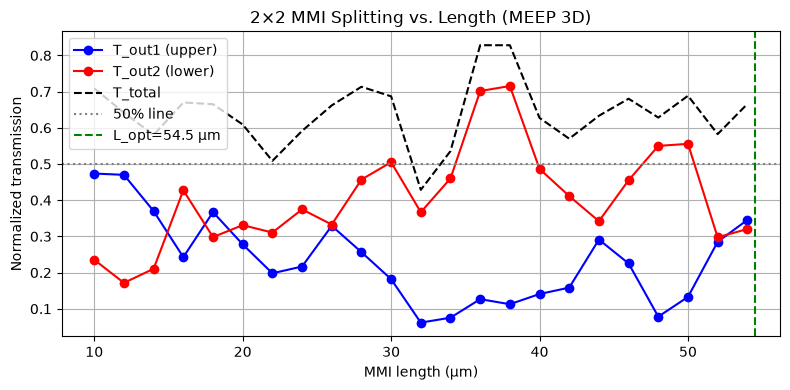

In [31]:
# ── Plot ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(L_sweep, T_upper, 'b-o', label='T_out1 (upper)')
plt.plot(L_sweep, T_lower, 'r-o', label='T_out2 (lower)')
plt.plot(L_sweep, T_total, 'k--', label='T_total')
plt.axhline(0.5, color='gray', linestyle=':', label='50% line')
if L_opt: plt.axvline(L_opt, color='green', linestyle='--', label=f'L_opt={L_opt:.1f} µm')
plt.xlabel('MMI length (µm)')
plt.ylabel('Normalized transmission')
plt.title('2×2 MMI Splitting vs. Length (MEEP 3D)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('mmi_sweep.png', dpi=150)